## 1.  Configuration & Structure des dossiers

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Chemins absolus basés sur la position du notebook ──────────
NOTEBOOK_DIR = os.path.abspath('')
BASE_DIR     = os.path.dirname(NOTEBOOK_DIR)        # mednova-ai/
DATA_DIR     = os.path.join(BASE_DIR, 'data')
MODELS_DIR   = os.path.join(BASE_DIR, 'models')

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('📂 Structure du projet :')
print(f'   Base     → {BASE_DIR}')
print(f'   data/    → {DATA_DIR}')
print(f'   models/  → {MODELS_DIR}')
print(f'   notebooks/ (dossier courant)')

# ── Configuration graphique globale ────────────────────────────
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style('whitegrid')

MEDNOVA_BLUE   = '#1A5276'
MEDNOVA_LIGHT  = '#AED6F1'
MEDNOVA_RED    = '#E74C3C'
MEDNOVA_GREEN  = '#2ECC71'
MEDNOVA_ORANGE = '#F39C12'

print(f'\n✅ Librairies importées')
print(f'   pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')

📂 Structure du projet :
   Base     → C:\Users\HP\Desktop\ing4\MedNova\MedNova
   data/    → C:\Users\HP\Desktop\ing4\MedNova\MedNova\data
   models/  → C:\Users\HP\Desktop\ing4\MedNova\MedNova\models
   notebooks/ (dossier courant)

✅ Librairies importées
   pandas 2.3.3 | numpy 2.4.3 | seaborn 0.13.2


## 2.  Chargement du dataset

In [2]:
from ucimlrepo import fetch_ucirepo

support2 = fetch_ucirepo(id=880)
df = pd.concat([support2.data.features, support2.data.targets], axis=1)

df.to_csv(os.path.join(DATA_DIR, 'support2.csv'), index=False)

print(f'✅ Dataset chargé et sauvegardé → data/support2.csv')
print(f'📊 Dimensions : {df.shape[0]:,} patients × {df.shape[1]} variables')
df.head()

✅ Dataset chargé et sauvegardé → data/support2.csv
📊 Dimensions : 9,105 patients × 45 variables


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,7.459961,NaN,NaN,NaN,7.0,7.0,7.0,0,0,NaN
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,7.250000,NaN,NaN,NaN,NaN,1.0,1.0,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,7.459961,NaN,NaN,NaN,1.0,0.0,0.0,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,7.509766,NaN,NaN,NaN,NaN,2.0,2.0,0,0,no(M2 and SIP pres)


## 3. 🔍 Vue d'ensemble

In [3]:
dtype_df = pd.DataFrame({
    'Type'       : df.dtypes.values,
    'Non-nulls'  : df.count().values,
    'Nulls'      : df.isnull().sum().values,
    '% Manquant' : (df.isnull().sum().values / len(df) * 100).round(2)
}, index=df.columns)
print('=== TYPES DE DONNÉES ===')
print(dtype_df.to_string())

=== TYPES DE DONNÉES ===
             Type  Non-nulls  Nulls  % Manquant
age       float64       9105      0        0.00
sex        object       9105      0        0.00
dzgroup    object       9105      0        0.00
dzclass    object       9105      0        0.00
num.co      int64       9105      0        0.00
edu       float64       7471   1634       17.95
income     object       6123   2982       32.75
scoma     float64       9104      1        0.01
charges   float64       8933    172        1.89
totcst    float64       8217    888        9.75
totmcst   float64       5630   3475       38.17
avtisst   float64       9023     82        0.90
race       object       9063     42        0.46
sps       float64       9104      1        0.01
aps       float64       9104      1        0.01
surv2m    float64       9104      1        0.01
surv6m    float64       9104      1        0.01
hday        int64       9105      0        0.00
diabetes    int64       9105      0        0.00
dementia    int

In [4]:
print('=== STATISTIQUES DESCRIPTIVES ===')
df.describe(include='all').T

=== STATISTIQUES DESCRIPTIVES ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,9105.0,NaN,NaN,NaN,62.650823,15.59371,18.04199,52.797,64.85699,73.99896,101.84796
sex,9105,2,male,5125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dzgroup,9105,8,ARF/MOSF w/Sepsis,3515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dzclass,9105,4,ARF/MOSF,4227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num.co,9105.0,NaN,NaN,NaN,1.868644,1.344409,0.0,1.0,2.0,3.0,9.0
edu,7471.0,NaN,NaN,NaN,11.747691,3.447743,0.0,10.0,12.0,14.0,31.0
income,6123,4,under $11k,2855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scoma,9104.0,NaN,NaN,NaN,12.058546,24.636694,0.0,0.0,0.0,9.0,100.0
charges,8933.0,NaN,NaN,NaN,59995.787811,102648.778198,1169.0,9740.0,25024.0,64598.0,1435423.0
totcst,8217.0,NaN,NaN,NaN,30825.867768,45780.820986,0.0,5929.5664,14452.7344,36087.9375,633212.0


## 4. 🕳️ Analyse des valeurs manquantes

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    '% manquant': missing_pct
}).sort_values('% manquant', ascending=False)
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0]

print(f'Colonnes avec valeurs manquantes : {len(missing_df)} / {df.shape[1]}')
print(missing_df.to_string())

Colonnes avec valeurs manquantes : 33 / 45
         Valeurs manquantes  % manquant
adlp                   5641       61.95
urine                  4862       53.40
glucose                4500       49.42
bun                    4352       47.80
totmcst                3475       38.17
alb                    3372       37.03
income                 2982       32.75
adls                   2867       31.49
bili                   2601       28.57
pafi                   2325       25.54
ph                     2284       25.09
prg2m                  1649       18.11
edu                    1634       17.95
prg6m                  1633       17.94
sfdm2                  1400       15.38
totcst                  888        9.75
wblc                    212        2.33
charges                 172        1.89
avtisst                  82        0.90
crea                     67        0.74
race                     42        0.46
dnrday                   30        0.33
dnr                      30        0.

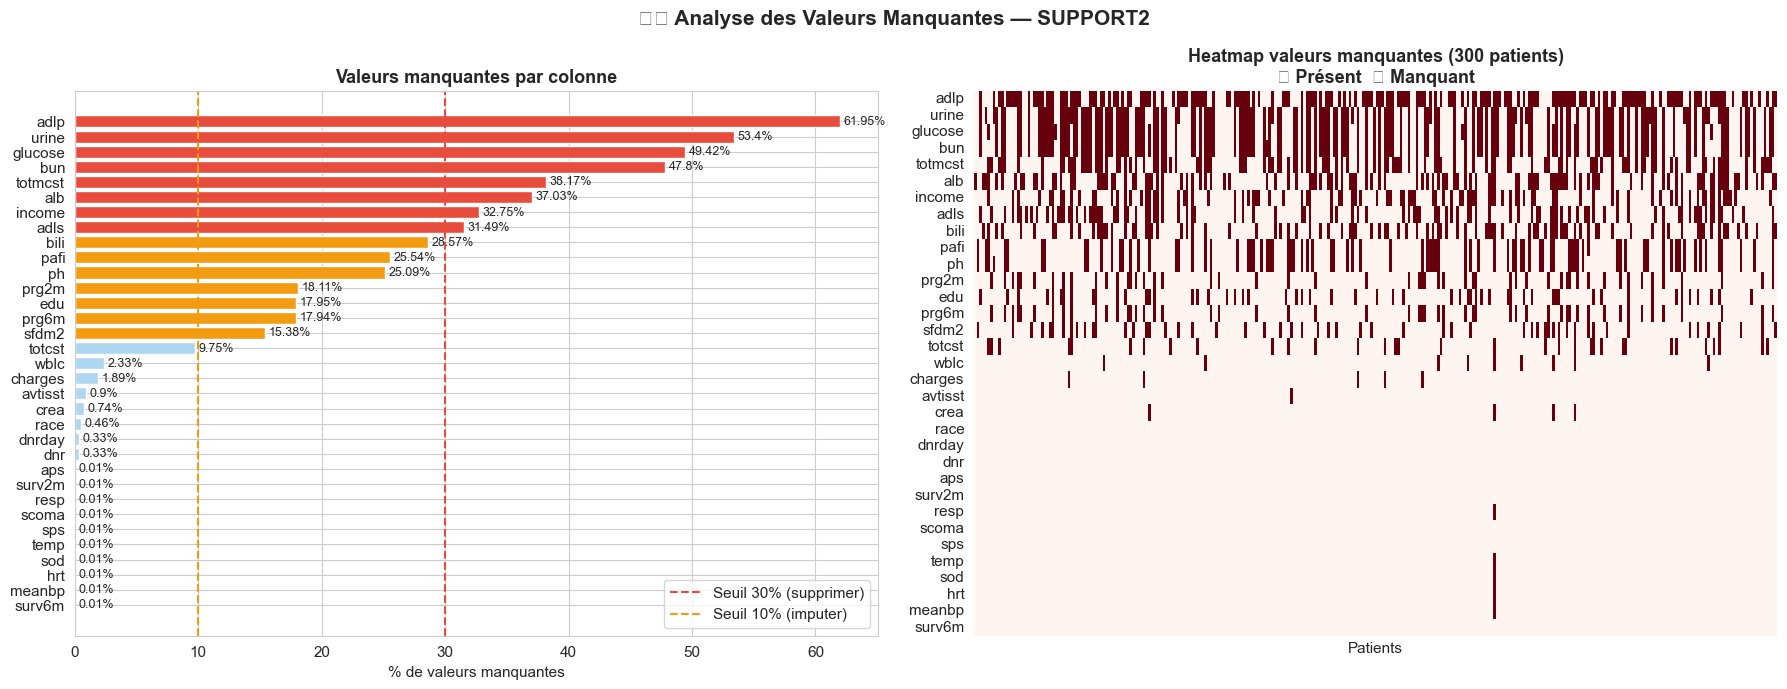

✅ Sauvegardé → data/missing_values_analysis.png


In [6]:
cols_with_missing = missing_df.index.tolist()

colors = [MEDNOVA_RED if x > 30 else MEDNOVA_ORANGE if x > 10 else MEDNOVA_LIGHT
          for x in missing_df['% manquant']]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(missing_df.index, missing_df['% manquant'], color=colors, edgecolor='white')
axes[0].axvline(x=30, color=MEDNOVA_RED,    linestyle='--', label='Seuil 30% (supprimer)')
axes[0].axvline(x=10, color=MEDNOVA_ORANGE, linestyle='--', label='Seuil 10% (imputer)')
axes[0].set_xlabel('% de valeurs manquantes')
axes[0].set_title('Valeurs manquantes par colonne')
axes[0].legend(); axes[0].invert_yaxis()
for i, pct in enumerate(missing_df['% manquant']):
    axes[0].text(pct+0.3, i, f'{pct}%', va='center', fontsize=9)

sample = df[cols_with_missing].sample(n=min(300, len(df)), random_state=42)
sns.heatmap(sample.isnull().astype(int).T, cmap='Reds', cbar=False,
            ax=axes[1], yticklabels=True, xticklabels=False)
axes[1].set_title('Heatmap valeurs manquantes (300 patients)\n🟢 Présent  🔴 Manquant')
axes[1].set_xlabel('Patients')

plt.suptitle('🕳️ Analyse des Valeurs Manquantes — SUPPORT2', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'missing_values_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/missing_values_analysis.png')

## 5. 🎯 Analyse des variables cibles

In [7]:
target_candidates = ['death','d.time','hospdead','charges','totcst','totmcst']
available_targets = [c for c in target_candidates if c in df.columns]
print('Variables cibles disponibles :')
for col in available_targets:
    n_m = df[col].isnull().sum()
    print(f'  • {col:15s} → type: {df[col].dtype}, manquants: {n_m} ({n_m/len(df)*100:.1f}%)')

Variables cibles disponibles :
  • death           → type: int64, manquants: 0 (0.0%)
  • hospdead        → type: int64, manquants: 0 (0.0%)
  • charges         → type: float64, manquants: 172 (1.9%)
  • totcst          → type: float64, manquants: 888 (9.8%)
  • totmcst         → type: float64, manquants: 3475 (38.2%)


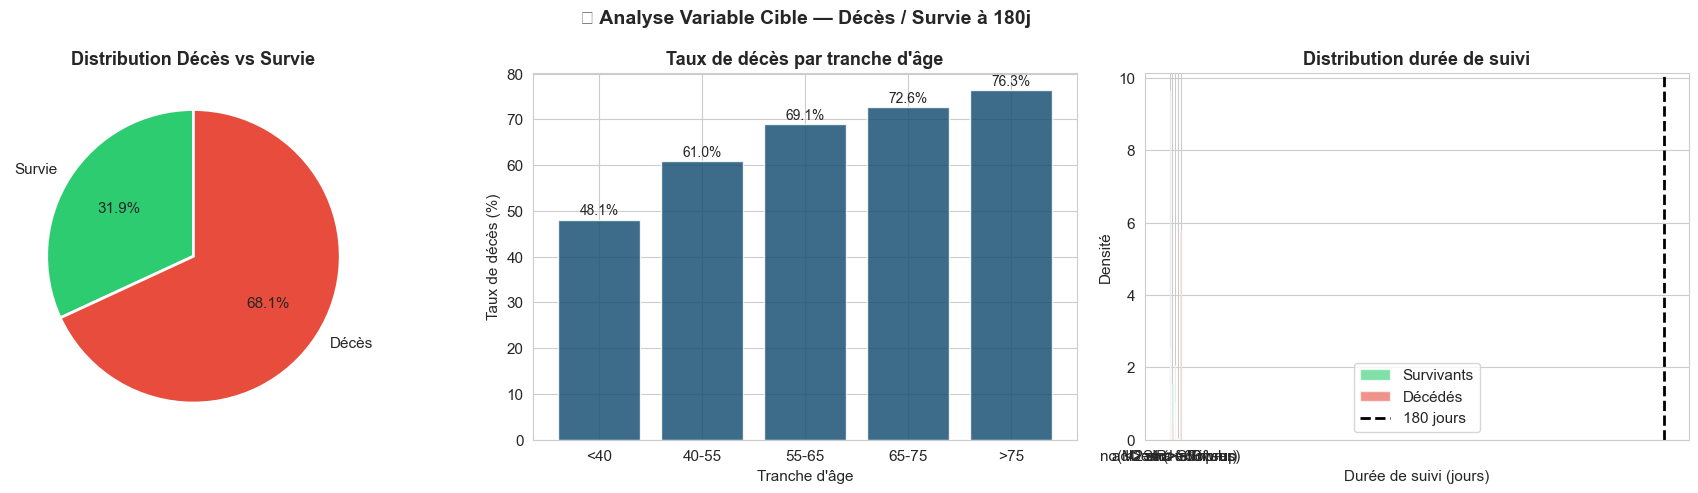

✅ Sauvegardé → data/target_analysis.png


In [8]:
if 'death' in df.columns:
    if 'age' in df.columns:
        df['age_group'] = pd.cut(df['age'], bins=[0,40,55,65,75,120],
                                  labels=['<40','40-55','55-65','65-75','>75'])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    death_counts = df['death'].value_counts().sort_index()
    axes[0].pie(death_counts.values, labels=['Survie','Décès'], autopct='%1.1f%%',
                colors=[MEDNOVA_GREEN, MEDNOVA_RED], startangle=90,
                wedgeprops={'edgecolor':'white','linewidth':2})
    axes[0].set_title('Distribution Décès vs Survie')

    if 'age_group' in df.columns:
        death_age = df.groupby('age_group', observed=True)['death'].mean() * 100
        bars = axes[1].bar(death_age.index.astype(str), death_age.values,
                           color=MEDNOVA_BLUE, edgecolor='white', alpha=0.85)
        axes[1].set_xlabel("Tranche d'âge"); axes[1].set_ylabel('Taux de décès (%)')
        axes[1].set_title("Taux de décès par tranche d'âge")
        for bar, val in zip(bars, death_age.values):
            axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                         f'{val:.1f}%', ha='center', fontsize=10)

    time_col = next((c for c in ['d.time','sfdm2'] if c in df.columns), None)
    if time_col:
        axes[2].hist(df[df['death']==0][time_col].dropna(), bins=40, alpha=0.6,
                      color=MEDNOVA_GREEN, label='Survivants', density=True)
        axes[2].hist(df[df['death']==1][time_col].dropna(), bins=40, alpha=0.6,
                      color=MEDNOVA_RED, label='Décédés', density=True)
        axes[2].axvline(x=180, color='black', linestyle='--', linewidth=2, label='180 jours')
        axes[2].set_xlabel('Durée de suivi (jours)'); axes[2].set_ylabel('Densité')
        axes[2].set_title('Distribution durée de suivi'); axes[2].legend()

    plt.suptitle('🎯 Analyse Variable Cible — Décès / Survie à 180j', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'target_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Sauvegardé → data/target_analysis.png')

## 6. 📊 Analyse univariée — Variables numériques

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_from_features = ['death','hospdead','slos','charges','totcst','totmcst']
numeric_features = [c for c in numeric_cols if c not in exclude_from_features]

vitals = [c for c in ['age','meanbp','hrt','resp','temp','wblc','sod','crea','bili','alb','pafi'] if c in df.columns]
scores = [c for c in ['aps','sps','surv2m','surv6m','avtisst','ph','glucose','bun','urine'] if c in df.columns]

print(f'Numériques totales      : {len(numeric_cols)}')
print(f'Features (hors cibles) : {len(numeric_features)}')
print(f'Variables vitales       : {vitals}')
print(f'Scores cliniques        : {scores}')

Numériques totales      : 37
Features (hors cibles) : 32
Variables vitales       : ['age', 'meanbp', 'hrt', 'resp', 'temp', 'wblc', 'sod', 'crea', 'bili', 'alb', 'pafi']
Scores cliniques        : ['aps', 'sps', 'surv2m', 'surv6m', 'avtisst', 'ph', 'glucose', 'bun', 'urine']


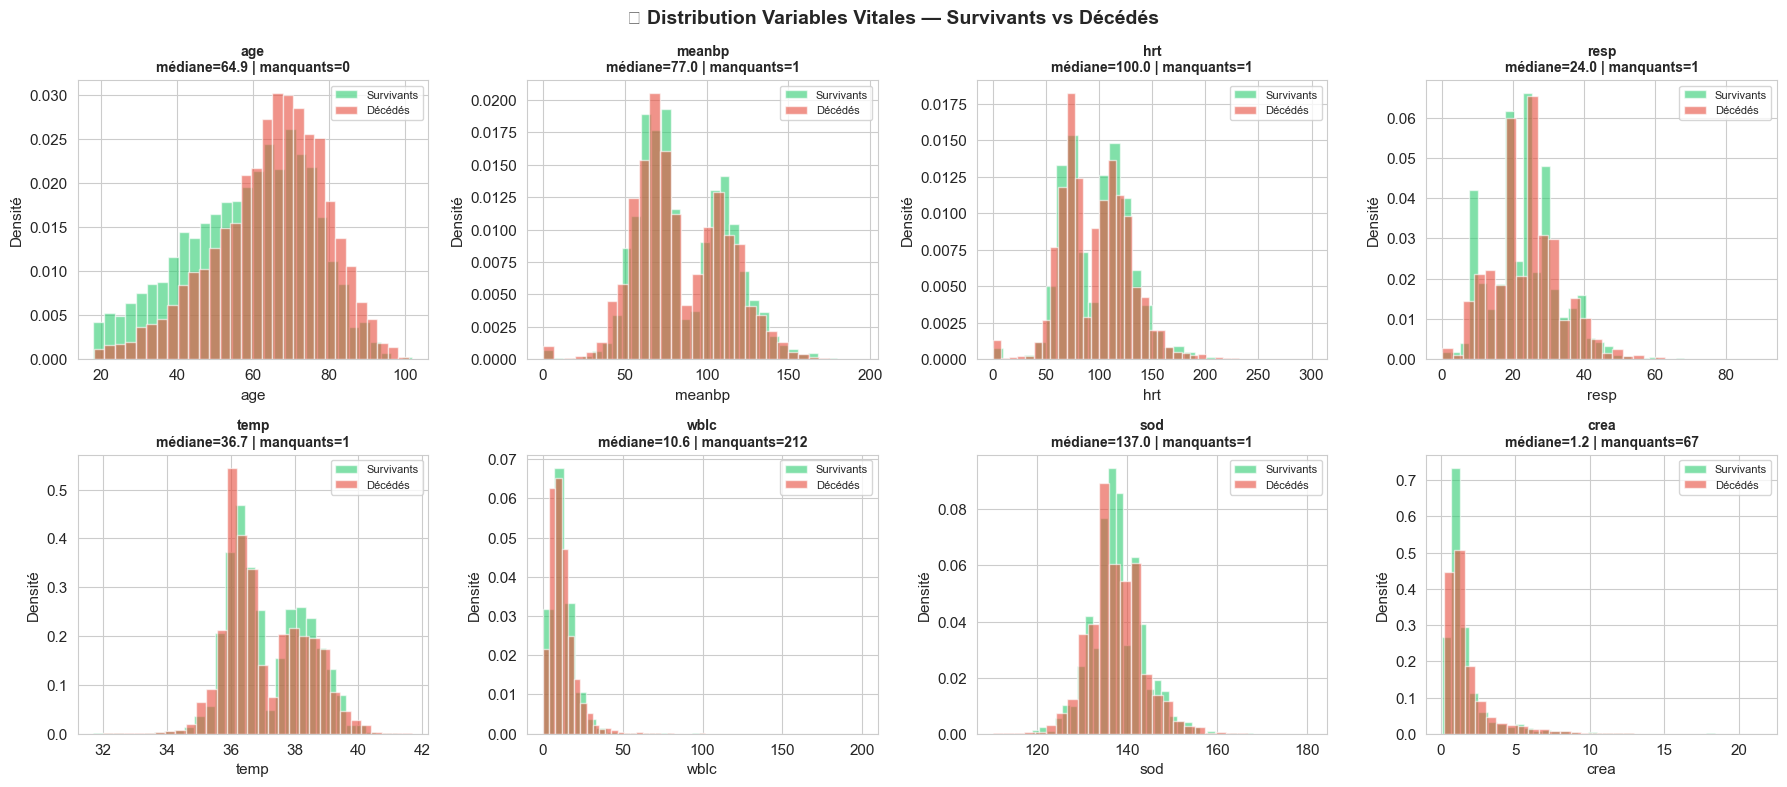

✅ Sauvegardé → data/univariate_vitals.png


In [10]:
plot_cols = vitals[:8] if len(vitals) >= 8 else vitals
n = len(plot_cols); ncols = 4; nrows = (n+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if 'death' in df.columns:
        axes[i].hist(df[df['death']==0][col].dropna(), bins=30, alpha=0.6, color=MEDNOVA_GREEN, label='Survivants', density=True)
        axes[i].hist(df[df['death']==1][col].dropna(), bins=30, alpha=0.6, color=MEDNOVA_RED,   label='Décédés',   density=True)
        axes[i].legend(fontsize=8)
    axes[i].set_title(f'{col}\nmédiane={df[col].median():.1f} | manquants={df[col].isnull().sum()}', fontsize=10)
    axes[i].set_xlabel(col); axes[i].set_ylabel('Densité')

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('📊 Distribution Variables Vitales — Survivants vs Décédés', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'univariate_vitals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/univariate_vitals.png')

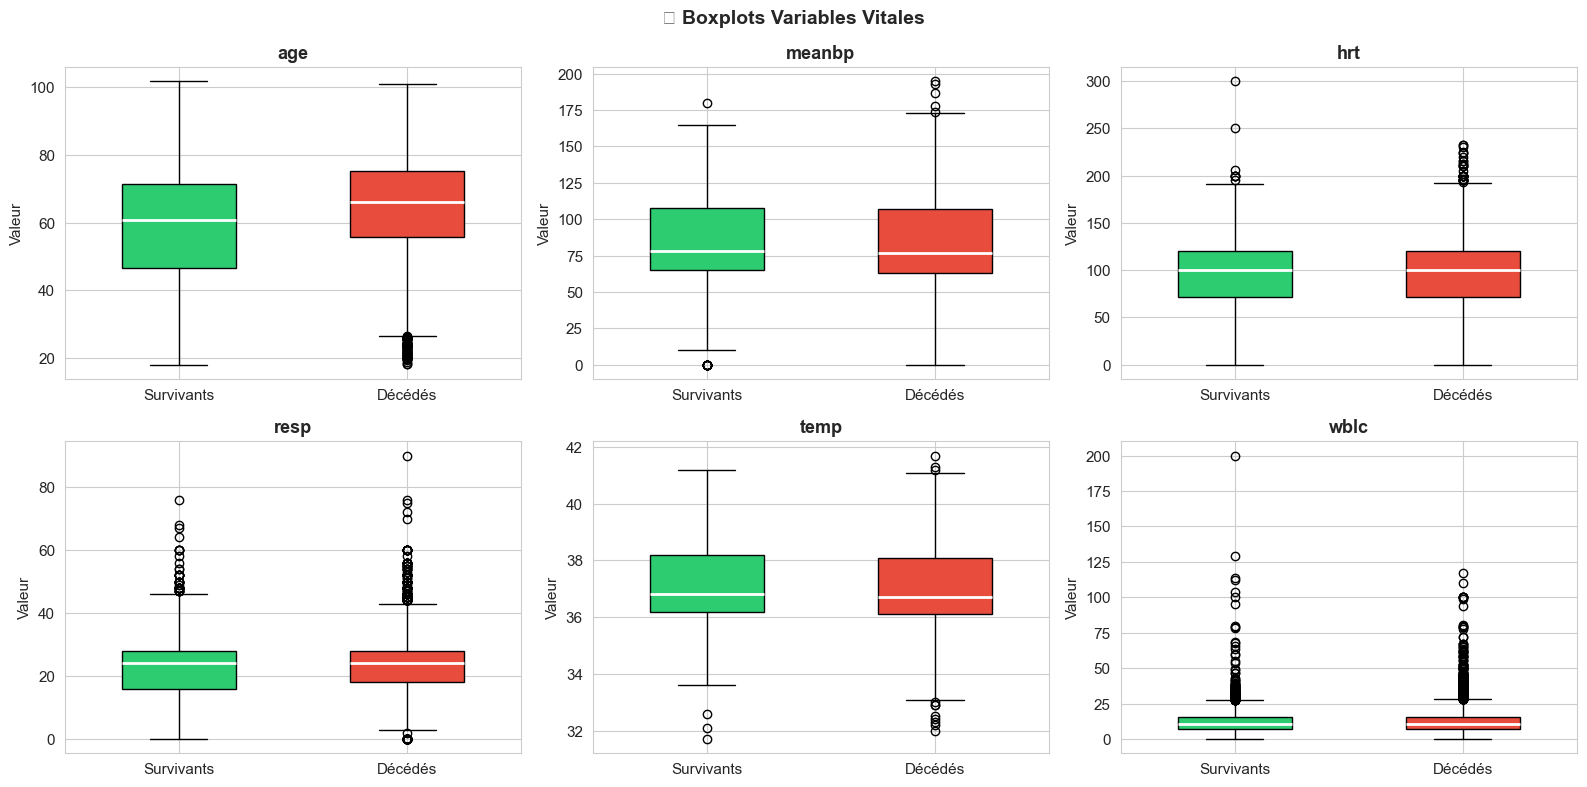

✅ Sauvegardé → data/boxplots_vitals.png


In [11]:
plot_cols = vitals[:6] if len(vitals) >= 6 else vitals
n = len(plot_cols); ncols = 3; nrows = (n+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*4))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if 'death' in df.columns:
        bp = axes[i].boxplot([df[df['death']==0][col].dropna(), df[df['death']==1][col].dropna()],
                              patch_artist=True, widths=0.5, medianprops={'color':'white','linewidth':2})
        bp['boxes'][0].set_facecolor(MEDNOVA_GREEN); bp['boxes'][1].set_facecolor(MEDNOVA_RED)
        axes[i].set_xticklabels(['Survivants','Décédés'])
    axes[i].set_title(col); axes[i].set_ylabel('Valeur')

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('📦 Boxplots Variables Vitales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'boxplots_vitals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/boxplots_vitals.png')

## 7. 📋 Analyse univariée — Variables catégorielles

In [12]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print(f'Variables catégorielles : {len(cat_cols)}')
for col in cat_cols:
    top_val = df[col].value_counts().index[0]
    top_pct = df[col].value_counts().iloc[0] / df[col].count() * 100
    print(f'  {col:20s} → {df[col].nunique():3d} modalités | top: "{top_val}" ({top_pct:.1f}%)')

Variables catégorielles : 9
  sex                  →   2 modalités | top: "male" (56.3%)
  dzgroup              →   8 modalités | top: "ARF/MOSF w/Sepsis" (38.6%)
  dzclass              →   4 modalités | top: "ARF/MOSF" (46.4%)
  income               →   4 modalités | top: "under $11k" (46.6%)
  race                 →   5 modalités | top: "white" (79.3%)
  ca                   →   3 modalités | top: "no" (65.8%)
  dnr                  →   3 modalités | top: "no dnr" (64.8%)
  sfdm2                →   5 modalités | top: "<2 mo. follow-up" (40.5%)
  age_group            →   5 modalités | top: "65-75" (26.9%)


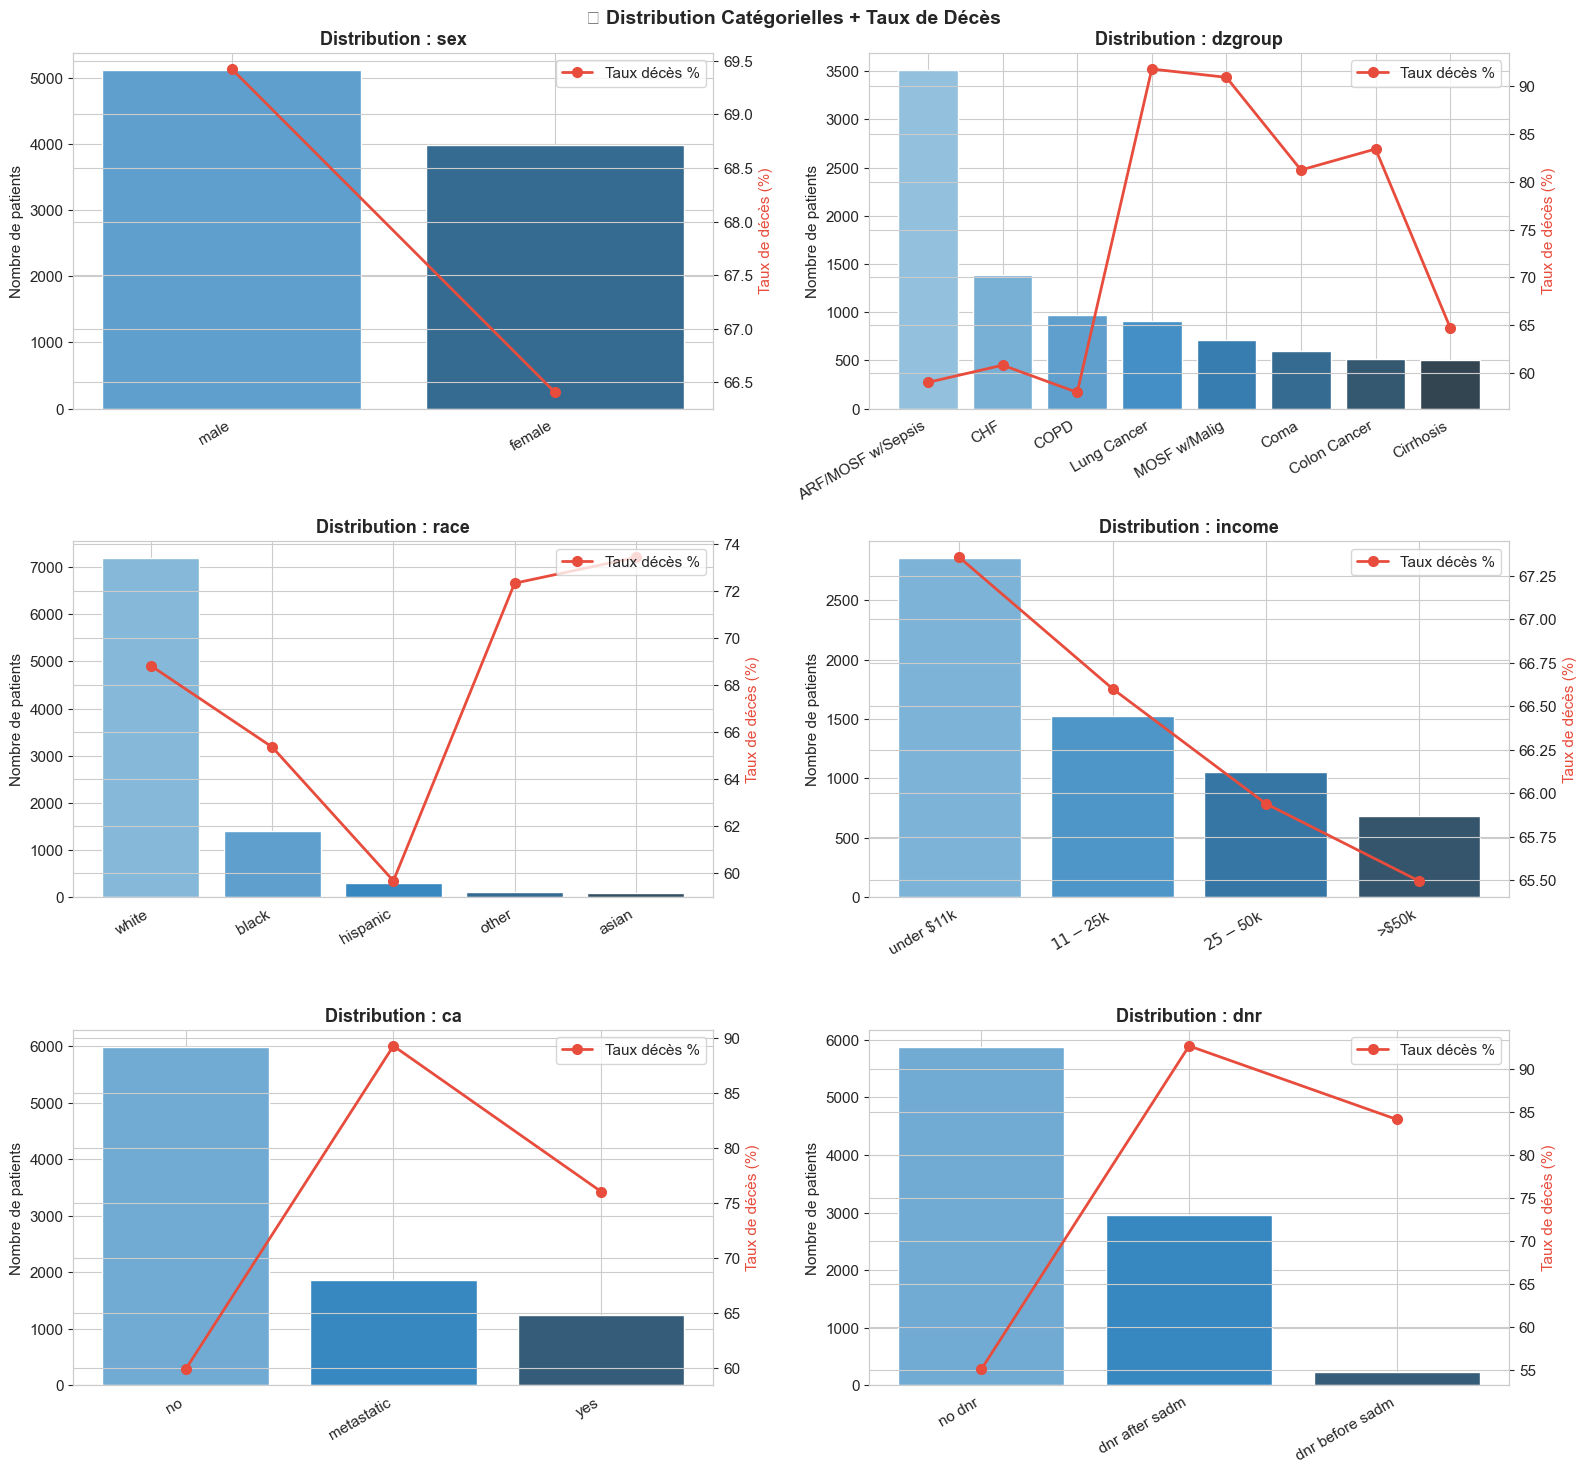

✅ Sauvegardé → data/categorical_analysis.png


In [13]:
important_cats = [c for c in ['sex','dzgroup','race','income','ca','dnr'] if c in df.columns]
n = len(important_cats); ncols = 2; nrows = (n+1)//2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*5))
axes = axes.flatten()

for i, col in enumerate(important_cats):
    counts = df[col].value_counts()
    axes[i].bar(range(len(counts)), counts.values,
                color=sns.color_palette('Blues_d', len(counts)), edgecolor='white')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=30, ha='right')
    axes[i].set_title(f'Distribution : {col}'); axes[i].set_ylabel('Nombre de patients')
    if 'death' in df.columns:
        death_rate = df.groupby(col, observed=True)['death'].mean() * 100
        ax2 = axes[i].twinx()
        ax2.plot(range(len(death_rate.reindex(counts.index))), death_rate.reindex(counts.index).values,
                 'o-', color=MEDNOVA_RED, linewidth=2, markersize=7, label='Taux décès %')
        ax2.set_ylabel('Taux de décès (%)', color=MEDNOVA_RED); ax2.legend(loc='upper right')

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('📋 Distribution Catégorielles + Taux de Décès', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'categorical_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/categorical_analysis.png')

## 8. 🔗 Analyse multivariée & corrélations

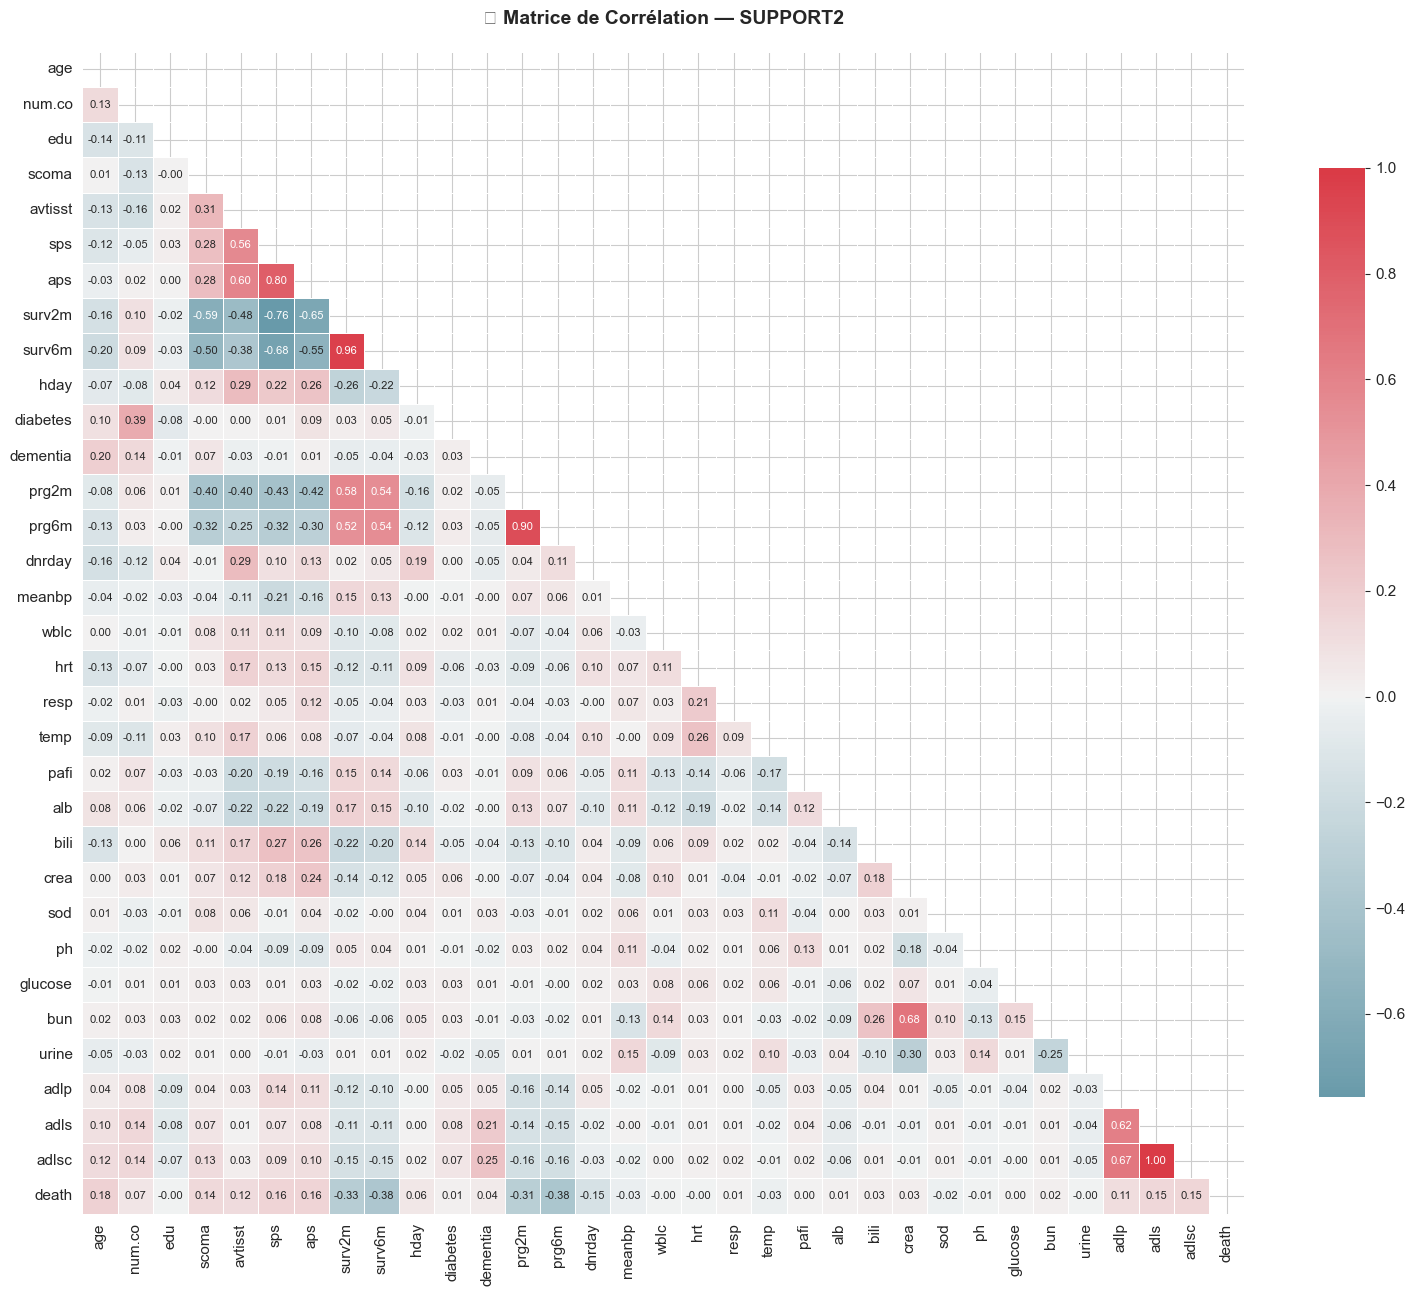

✅ Sauvegardé → data/correlation_matrix.png


In [14]:
corr_cols = [c for c in numeric_features + ['death'] if c in df.columns]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, annot=True, fmt='.2f', annot_kws={'size':8},
            square=True, linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('🔗 Matrice de Corrélation — SUPPORT2', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/correlation_matrix.png')

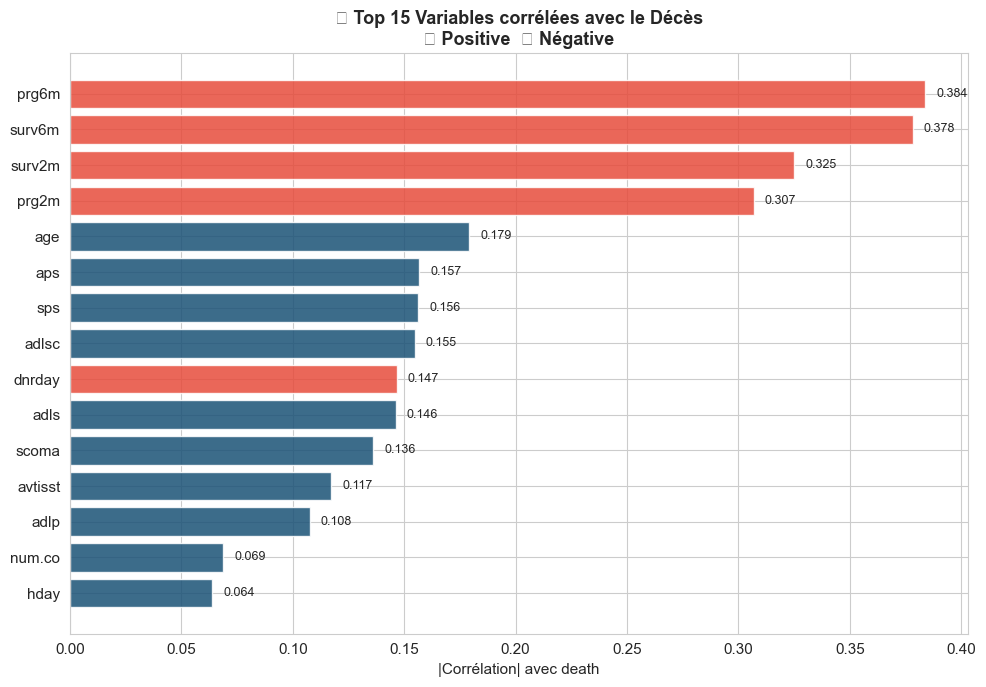

✅ Sauvegardé → data/feature_correlation_target.png

Top 10 features :
   prg6m           : |r| = 0.384
   surv6m          : |r| = 0.378
   surv2m          : |r| = 0.325
   prg2m           : |r| = 0.307
   age             : |r| = 0.179
   aps             : |r| = 0.157
   sps             : |r| = 0.156
   adlsc           : |r| = 0.155
   dnrday          : |r| = 0.147
   adls            : |r| = 0.146


In [15]:
if 'death' in corr_matrix.columns:
    target_corr = corr_matrix['death'].drop('death').abs().sort_values(ascending=False)
    top_features = target_corr.head(15)
    colors = [MEDNOVA_RED if corr_matrix['death'][f] < 0 else MEDNOVA_BLUE for f in top_features.index]

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(top_features.index, top_features.values, color=colors, edgecolor='white', alpha=0.85)
    ax.set_xlabel('|Corrélation| avec death')
    ax.set_title('🏆 Top 15 Variables corrélées avec le Décès\n🔵 Positive  🔴 Négative', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    for bar, val in zip(bars, top_features.values):
        ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'feature_correlation_target.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Sauvegardé → data/feature_correlation_target.png')
    print('\nTop 10 features :')
    for feat, val in top_features.head(10).items():
        print(f'   {feat:15s} : |r| = {val:.3f}')

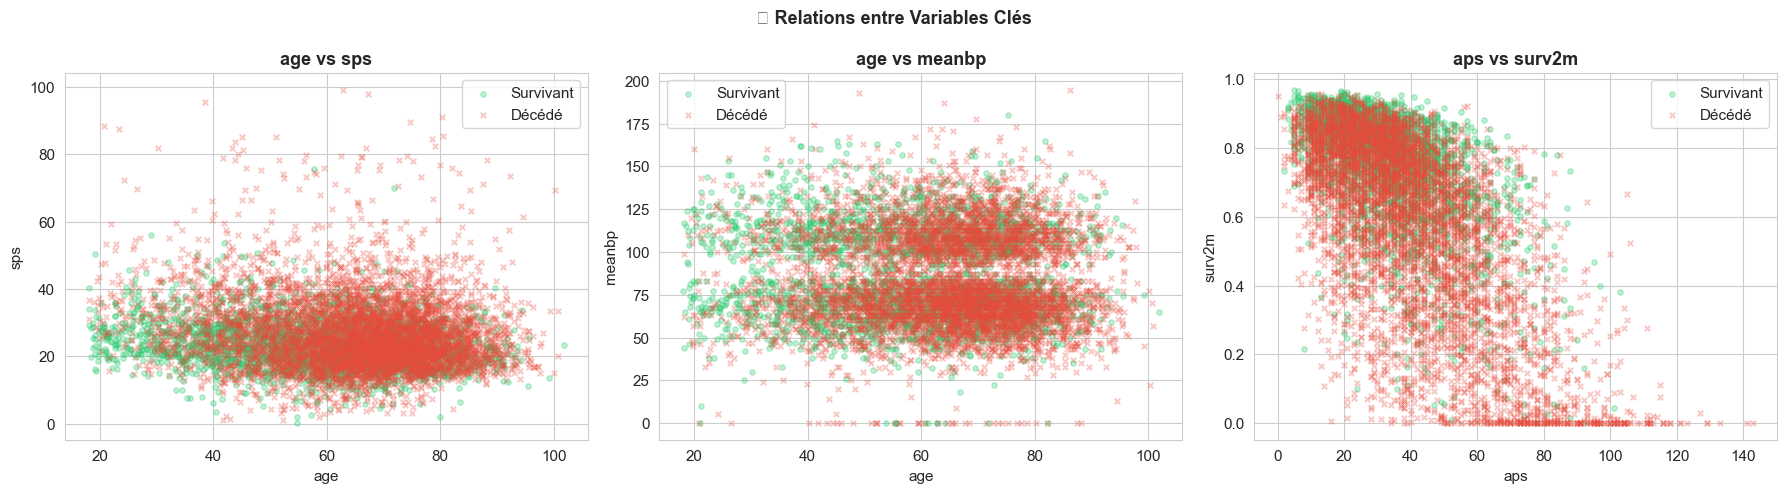

✅ Sauvegardé → data/scatter_analysis.png


In [16]:
key_pairs = [(a,b) for a,b in [('age','sps'),('age','meanbp'),('aps','surv2m')]
              if a in df.columns and b in df.columns]
if key_pairs and 'death' in df.columns:
    fig, axes = plt.subplots(1, len(key_pairs), figsize=(6*len(key_pairs), 5))
    if len(key_pairs) == 1: axes = [axes]
    for i, (x_col, y_col) in enumerate(key_pairs):
        subset = df[[x_col, y_col, 'death']].dropna()
        for label, color, marker in [(0, MEDNOVA_GREEN, 'o'), (1, MEDNOVA_RED, 'x')]:
            sub = subset[subset['death']==label]
            axes[i].scatter(sub[x_col], sub[y_col], c=color, alpha=0.3, s=15,
                             marker=marker, label='Survivant' if label==0 else 'Décédé')
        axes[i].set_xlabel(x_col); axes[i].set_ylabel(y_col)
        axes[i].set_title(f'{x_col} vs {y_col}'); axes[i].legend()
    plt.suptitle('🔍 Relations entre Variables Clés', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'scatter_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Sauvegardé → data/scatter_analysis.png')

## 9. 🚨 Détection des outliers

In [17]:
def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1-1.5*IQR, Q3+1.5*IQR
    return ((series < lower) | (series > upper)).sum(), lower, upper

outlier_report = []
for col in vitals + scores:
    if col in df.columns:
        series = df[col].dropna()
        n_out, lower, upper = detect_outliers_iqr(series)
        outlier_report.append({'Variable': col, 'N outliers': n_out,
                                '% outliers': round(n_out/len(series)*100, 2),
                                'Borne inf': round(lower,2), 'Borne sup': round(upper,2)})

outlier_df = pd.DataFrame(outlier_report).sort_values('% outliers', ascending=False)
print('=== DÉTECTION DES OUTLIERS (IQR) ===')
print(outlier_df.to_string(index=False))

=== DÉTECTION DES OUTLIERS (IQR) ===
Variable  N outliers  % outliers  Borne inf  Borne sup
    bili         926       14.24      -1.60       4.00
    crea         987       10.92      -0.60       3.40
 glucose         272        5.91     -24.50     315.50
     bun         267        5.62     -28.00      84.00
    wblc         399        4.49      -5.45      27.75
      ph         260        3.81       7.25       7.60
    resp         313        3.44       3.00      43.00
  surv2m         307        3.37       0.03       1.30
     sps         283        3.11       2.20      47.00
     sod         256        2.81     123.50     151.50
   urine          92        2.17   -1586.25    5751.75
     aps         178        1.96     -16.00      88.00
    pafi          90        1.33     -69.39     529.23
     age          56        0.62      20.99     105.80
 avtisst          43        0.48     -17.50      61.17
     hrt          40        0.44       0.00     192.00
     alb          15        

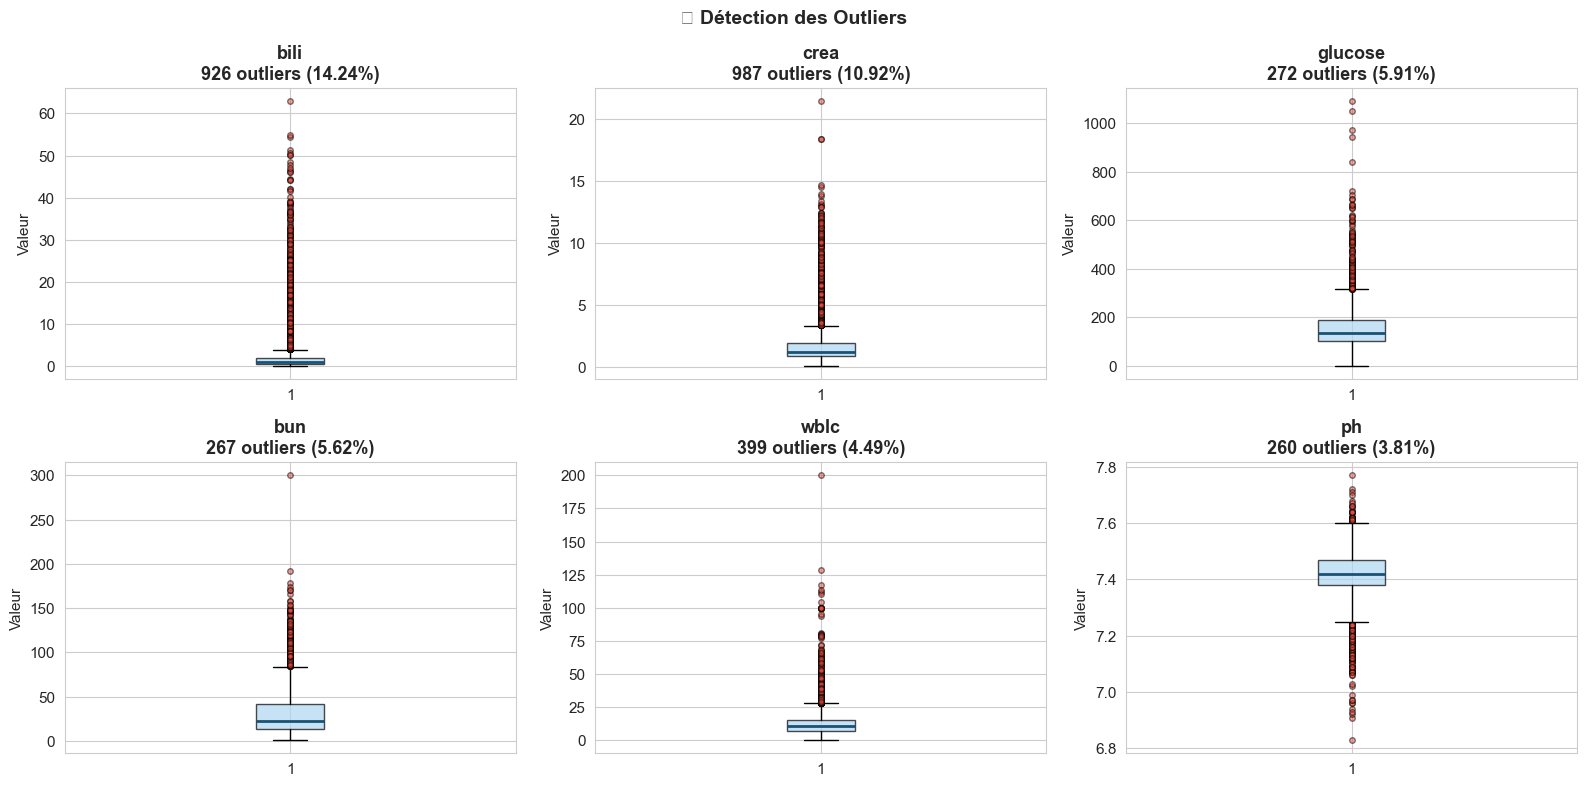

✅ Sauvegardé → data/outliers_detection.png


In [18]:
top_outlier_vars = outlier_df.nlargest(6, '% outliers')['Variable'].tolist()
top_outlier_vars = [v for v in top_outlier_vars if v in df.columns]

if top_outlier_vars:
    ncols = 3; nrows = (len(top_outlier_vars)+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*4))
    axes = axes.flatten()
    for i, col in enumerate(top_outlier_vars):
        axes[i].boxplot(df[col].dropna(), patch_artist=True, vert=True,
                         boxprops={'facecolor':MEDNOVA_LIGHT,'alpha':0.7},
                         medianprops={'color':MEDNOVA_BLUE,'linewidth':2},
                         flierprops={'marker':'o','markerfacecolor':MEDNOVA_RED,'alpha':0.5,'markersize':4})
        n_out = outlier_df[outlier_df['Variable']==col]['N outliers'].values[0]
        pct   = outlier_df[outlier_df['Variable']==col]['% outliers'].values[0]
        axes[i].set_title(f'{col}\n{n_out} outliers ({pct}%)'); axes[i].set_ylabel('Valeur')
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle('🚨 Détection des Outliers', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'outliers_detection.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Sauvegardé → data/outliers_detection.png')

## 10. 📝 Rapport de synthèse

In [19]:
print('='*65)
print('  📋 RAPPORT DE SYNTHÈSE EDA — SUPPORT2 — MedNova AI')
print('='*65)
print(f'\n📊 DATASET')
print(f'   Patients      : {len(df):,}')
print(f'   Variables     : {df.shape[1]}')
print(f'   Numériques    : {len(df.select_dtypes(include=np.number).columns)}')
print(f'   Catégorielles : {len(df.select_dtypes(include="object").columns)}')

if 'death' in df.columns:
    mort_rate = df['death'].mean()*100
    print(f'\n🎯 VARIABLE CIBLE (death)')
    print(f'   Taux de décès  : {mort_rate:.1f}%')
    print(f'   Taux de survie : {100-mort_rate:.1f}%')
    eq = "Modéré (OK)" if 30 < mort_rate < 70 else "Fort → class_weight=balanced conseillé"
    print(f'   Déséquilibre   : {eq}')

total_miss = df.isnull().sum().sum()
cols_miss  = (df.isnull().sum() > 0).sum()
print(f'\n🕳️  VALEURS MANQUANTES')
print(f'   Total : {total_miss:,} cellules ({total_miss/(df.shape[0]*df.shape[1])*100:.1f}%)')
print(f'   Colonnes impactées : {cols_miss}/{df.shape[1]}')
print(f'   🔴 > 30% : {list(missing_df[missing_df["% manquant"] > 30].index)}')
print(f'   🟡 10-30%: {list(missing_df[(missing_df["% manquant"]>10)&(missing_df["% manquant"]<=30)].index)}')
print(f'   🟢 < 10% : {list(missing_df[missing_df["% manquant"] <= 10].index)}')

print(f'\n🔧 RECOMMANDATIONS (Semaine 2)')
for i,r in enumerate(['Supprimer colonnes > 50% manquantes','Imputation médiane (numériques)',
    'Winsorizing 1%-99%','OneHotEncoder (catégorielles)','RobustScaler','class_weight=balanced'], 1):
    print(f'   {i}. {r}')

print(f'\n🏆 TOP FEATURES')
if 'death' in corr_matrix.columns:
    for feat, val in corr_matrix['death'].drop('death').abs().nlargest(5).items():
        print(f'   ✅ {feat:15s} : |r| = {val:.3f}')

print(f'\n📂 FICHIERS GÉNÉRÉS dans data/')
for f in sorted(os.listdir(DATA_DIR)): print(f'   • {f}')
print('='*65)

df.to_csv(os.path.join(DATA_DIR, 'support2_raw.csv'), index=False)
print('\n✅ support2_raw.csv → data/')
print('🚀 Semaine 1 terminée — Prêt pour la Semaine 2 !')

  📋 RAPPORT DE SYNTHÈSE EDA — SUPPORT2 — MedNova AI

📊 DATASET
   Patients      : 9,105
   Variables     : 46
   Numériques    : 37
   Catégorielles : 8

🎯 VARIABLE CIBLE (death)
   Taux de décès  : 68.1%
   Taux de survie : 31.9%
   Déséquilibre   : Modéré (OK)

🕳️  VALEURS MANQUANTES
   Total : 47,110 cellules (11.2%)
   Colonnes impactées : 33/46
   🔴 > 30% : ['adlp', 'urine', 'glucose', 'bun', 'totmcst', 'alb', 'income', 'adls']
   🟡 10-30%: ['bili', 'pafi', 'ph', 'prg2m', 'edu', 'prg6m', 'sfdm2']
   🟢 < 10% : ['totcst', 'wblc', 'charges', 'avtisst', 'crea', 'race', 'dnrday', 'dnr', 'aps', 'surv2m', 'resp', 'scoma', 'sps', 'temp', 'sod', 'hrt', 'meanbp', 'surv6m']

🔧 RECOMMANDATIONS (Semaine 2)
   1. Supprimer colonnes > 50% manquantes
   2. Imputation médiane (numériques)
   3. Winsorizing 1%-99%
   4. OneHotEncoder (catégorielles)
   5. RobustScaler
   6. class_weight=balanced

🏆 TOP FEATURES
   ✅ prg6m           : |r| = 0.384
   ✅ surv6m          : |r| = 0.378
   ✅ surv2m       